In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("feature_engineered_dataset.csv")

print("Dataset Shape:", df.shape)

df.head()


Dataset Shape: (4566, 21)


,xrCompositeLandUseID,xrBuildingTypeID,LocationStartNumber,StreetNameAndWay,xrPrimaryNeighborhoodID,LandSF,TotalFinishedArea,LivingUnits,OwnerLastName,SaleDate,...,TotalAppraisedValue,xrSalesValidityID,xrDeedID,AssrLandUse,WasZeroPrice,LogSalePrice,SaleYear,SaleMonth,PricePerSqft,AppraisalRatio
0,3,6.0,77,STAFFORD ST,2,6000.0,1092.0,1.0,WRIGHT,2024-07-01 00:00:00+00:00,...,187200,1,10,5,False,12.464587,2024,7,237.179487,1.383547
1,3,3.0,73,STAFFORD ST,2,6000.0,936.0,1.0,SANTANA,2022-04-26 00:00:00+00:00,...,192300,1,10,5,False,12.245298,2022,4,222.222222,1.081643
2,3,6.0,61,STAFFORD ST,2,6000.0,1111.0,1.0,MARTINEZ,2023-12-22 00:00:00+00:00,...,148400,1,10,5,False,11.736077,2023,12,112.511251,0.842318
3,3,6.0,211,NEWINGTON AVE,2,5040.0,1684.0,1.0,CAHUANA FLORES,2021-01-11 00:00:00+00:00,...,197900,1,10,5,False,12.083911,2021,1,105.106888,0.894391
4,3,3.0,18,BRISTOL ST,2,6000.0,900.0,1.0,NEGRON,2021-09-21 00:00:00+00:00,...,170700,1,10,5,False,12.144203,2021,9,208.888889,1.101347


In [2]:
# Feature and Target Selection

# Target variable
y = df['SalePrice']

# Remove target and leakage/unnecessary columns
X = df.drop(columns=[
    'SalePrice',
    'OwnerLastName',
    'StreetNameAndWay',
    'SaleDate',
    'LogSalePrice',
    'PricePerSqft',
    'AppraisalRatio'
], errors='ignore')

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeatures used:")
print(X.columns)


Feature Matrix Shape: (4566, 14)
Target Shape: (4566,)

Features used:
Index(['xrCompositeLandUseID', 'xrBuildingTypeID', 'LocationStartNumber',
       'xrPrimaryNeighborhoodID', 'LandSF', 'TotalFinishedArea', 'LivingUnits',
       'TotalAppraisedValue', 'xrSalesValidityID', 'xrDeedID', 'AssrLandUse',
       'WasZeroPrice', 'SaleYear', 'SaleMonth'],
      dtype='object')


In [3]:
# Encode categorical variables

X_encoded = pd.get_dummies(X, drop_first=True)

print("Encoded Feature Shape:", X_encoded.shape)

X_encoded.head()


Encoded Feature Shape: (4566, 14)


,xrCompositeLandUseID,xrBuildingTypeID,LocationStartNumber,xrPrimaryNeighborhoodID,LandSF,TotalFinishedArea,LivingUnits,TotalAppraisedValue,xrSalesValidityID,xrDeedID,AssrLandUse,WasZeroPrice,SaleYear,SaleMonth
0,3,6.0,77,2,6000.0,1092.0,1.0,187200,1,10,5,False,2024,7
1,3,3.0,73,2,6000.0,936.0,1.0,192300,1,10,5,False,2022,4
2,3,6.0,61,2,6000.0,1111.0,1.0,148400,1,10,5,False,2023,12
3,3,6.0,211,2,5040.0,1684.0,1.0,197900,1,10,5,False,2021,1
4,3,3.0,18,2,6000.0,900.0,1.0,170700,1,10,5,False,2021,9


In [4]:
# Train-Test Split and Feature Scaling

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)


Training set shape: (3652, 14)
Testing set shape: (914, 14)


In [5]:
# Train Support Vector Regression Model

from sklearn.svm import SVR

# Initialize SVR model
svr = SVR(kernel='rbf')

# Train model
svr.fit(X_train_scaled, y_train)

print("SVR model trained successfully!")


SVR model trained successfully!


In [6]:
# Predict using SVR model

svr_pred = svr.predict(X_test_scaled)

print("Predictions completed!")

print("\nFirst 10 Predictions:")
print(svr_pred[:10])


Predictions completed!

First 10 Predictions:
[230082.27127024 230020.46603786 230008.76248481 229998.63254049
 230322.57945217 230093.5172497  230114.61021766 230017.88129822
 230299.3132326  230027.3883061 ]


In [7]:
# Evaluate SVR model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, svr_pred)
rmse = np.sqrt(mean_squared_error(y_test, svr_pred))
r2 = r2_score(y_test, svr_pred)

print("SVR Model Performance")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)


SVR Model Performance
MAE: 695893.9061619043
RMSE: 2308534.4292580285
R2 Score: -0.0714164162480524


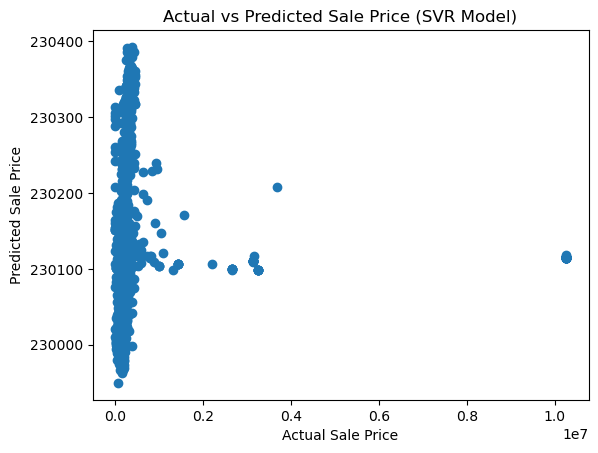

In [8]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(y_test, svr_pred)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted Sale Price (SVR Model)")

plt.show()


### Insight

Support Vector Regression (SVR) was implemented as an additional regression technique. 
However, the model performed poorly with an R² score of approximately -0.07. 
This indicates that the SVR model was unable to capture the complex relationships in the housing dataset.

Compared to tree-based models such as Random Forest and Decision Tree, SVR struggled to model the nonlinear interactions between features. 
This highlights that ensemble tree models are more suitable for real estate price prediction problems.


Although SVR is a powerful regression technique, it requires careful hyperparameter tuning and is sensitive to feature scaling and dataset size. In this case, ensemble models like Random Forest performed significantly better.